# 03 - Model Training

Trains and compares four classifiers on `data/processed/features.csv`: a **Gaussian classifier written from scratch** (as in the course lab), **kNN**, **SVM (RBF)** and **MLP**.

Pipeline in the order taught in the course (lab04): split -> scaling (estimated only on training) -> hyperparameter optimization with cross-validation -> training -> evaluation.

> First cell sets the working directory. Then Restart & Run All.

In [1]:
import os
while not os.path.isdir('data') and os.getcwd() != os.path.dirname(os.getcwd()):
    os.chdir('..')
print('Working dir:', os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, f1_score)

Working dir: C:\Users\Matteo\Desktop\Cybersecurity\2_Sem\Machine Learning\Progetto\Git.py_project


## Load the features and prepare X and y
`X` = the 25 numerical feature columns. `y` = the class (encoded 0..3 with LabelEncoder, needed by the from-scratch Gaussian).

In [2]:
data = pd.read_csv('data/processed/features.csv')
X = data.drop(columns=['type'])
le = LabelEncoder()
y = le.fit_transform(data['type'])
print('Features:', X.shape[1], '| Samples:', X.shape[0])
print('Classes:', list(le.classes_))

Features: 25 | Samples: 15000
Classes: ['benign', 'defacement', 'malware', 'phishing']


## Train / test split
20% test set, never seen during training (honest evaluation). `stratify=y` keeps the class proportions in both groups.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (12000, 25) | Test: (3000, 25)


## Feature scaling
MinMaxScaler estimated only on training and applied to the test set (never the other way). For kNN/SVM/MLP the scaler goes inside the Pipeline; here we prepare the scaled version for the manual Gaussian.

In [4]:
scaler = MinMaxScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

## Gaussian classifier written from scratch (from the course lab)
For each class it estimates (maximum likelihood) the prior, mean vector and covariance matrix. Classifies by log-likelihood + log-prior. `+1e-6*I` avoids singular covariances.

In [5]:
class CClassifierGaussian:
    """Gaussian classifier with maximum-likelihood estimates (full covariance)."""
    def fit(self, x, y):
        x = np.asarray(x, dtype=float)
        self.classes_ = np.unique(y)
        d = x.shape[1]
        self._priors, self._means, self._covs = [], [], []
        for k in self.classes_:
            xk = x[y == k]
            self._priors.append(len(xk) / len(x))
            self._means.append(xk.mean(axis=0))
            self._covs.append(np.cov(xk.T) + 1e-6 * np.eye(d))
        return self

    def _scores(self, x):
        s = [multivariate_normal(m, c, allow_singular=True).logpdf(x) + np.log(p)
             for m, c, p in zip(self._means, self._covs, self._priors)]
        return np.array(s).T

    def predict(self, x):
        x = np.asarray(x, dtype=float)
        return self.classes_[np.argmax(self._scores(x), axis=1)]

## Results collector + evaluation function
We compute balanced accuracy and macro-F1 (right metrics for imbalanced classes) plus the per-class report.

In [6]:
results = {}

def evaluate(name, y_pred):
    ba = balanced_accuracy_score(y_test, y_pred)
    mf1 = f1_score(y_test, y_pred, average='macro')
    results[name] = {'balanced_acc': round(ba, 3), 'macro_f1': round(mf1, 3)}
    print(f'\n=== {name} ===')
    print('Balanced accuracy:', round(ba, 3), '| Macro-F1:', round(mf1, 3))
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

In [7]:
gauss = CClassifierGaussian().fit(X_train_s, y_train)
evaluate('Gaussian', gauss.predict(X_test_s))


=== Gaussian ===
Balanced accuracy: 0.583 | Macro-F1: 0.503
              precision    recall  f1-score   support

      benign       0.82      0.40      0.53      2003
  defacement       0.24      0.98      0.38       446
     malware       0.94      0.82      0.88       111
    phishing       0.71      0.13      0.22       440

    accuracy                           0.46      3000
   macro avg       0.68      0.58      0.50      3000
weighted avg       0.72      0.46      0.48      3000



## kNN, SVM, MLP with hyperparameter optimization (GridSearchCV, 5-fold)
The scaler is inside each Pipeline, so it is re-estimated at every fold (no leakage). We optimize `balanced_accuracy`. Every tunable model uses grid search - this is the model selection the professor asked for.

In [8]:
knn = GridSearchCV(
    Pipeline([('scaler', MinMaxScaler()), ('clf', KNeighborsClassifier())]),
    {'clf__n_neighbors': [3, 5, 7, 11]},
    cv=5, scoring='balanced_accuracy', n_jobs=-1).fit(X_train, y_train)
print('Best k:', knn.best_params_)
evaluate('kNN', knn.predict(X_test))

Best k: {'clf__n_neighbors': 3}

=== kNN ===
Balanced accuracy: 0.8 | Macro-F1: 0.817
              precision    recall  f1-score   support

      benign       0.89      0.93      0.91      2003
  defacement       0.83      0.80      0.81       446
     malware       0.90      0.86      0.88       111
    phishing       0.73      0.62      0.67       440

    accuracy                           0.86      3000
   macro avg       0.84      0.80      0.82      3000
weighted avg       0.86      0.86      0.86      3000



In [9]:
# NB: the RBF-kernel SVM can take a few minutes on 12,000 samples. This is normal.
svm = GridSearchCV(
    Pipeline([('scaler', MinMaxScaler()), ('clf', SVC(kernel='rbf'))]),
    {'clf__C': [1, 10], 'clf__gamma': ['scale', 0.1]},
    cv=5, scoring='balanced_accuracy', n_jobs=-1).fit(X_train, y_train)
print('Best SVM parameters:', svm.best_params_)
evaluate('SVM (RBF)', svm.predict(X_test))

Best SVM parameters: {'clf__C': 10, 'clf__gamma': 'scale'}

=== SVM (RBF) ===
Balanced accuracy: 0.78 | Macro-F1: 0.809
              precision    recall  f1-score   support

      benign       0.88      0.96      0.92      2003
  defacement       0.84      0.88      0.86       446
     malware       0.96      0.84      0.89       111
    phishing       0.78      0.44      0.57       440

    accuracy                           0.87      3000
   macro avg       0.86      0.78      0.81      3000
weighted avg       0.86      0.87      0.86      3000



In [10]:
# MLP with hyperparameter search (vary hyperparameters with grid search, as requested)
mlp = GridSearchCV(
    Pipeline([('scaler', MinMaxScaler()),
              ('clf', MLPClassifier(max_iter=500, random_state=42))]),
    {'clf__hidden_layer_sizes': [(32, 16), (64, 32), (64,)],
     'clf__alpha': [1e-4, 1e-3, 1e-2]},
    cv=5, scoring='balanced_accuracy', n_jobs=-1).fit(X_train, y_train)
print('Best MLP parameters:', mlp.best_params_)
evaluate('MLP', mlp.predict(X_test))

Best MLP parameters: {'clf__alpha': 0.01, 'clf__hidden_layer_sizes': (64, 32)}

=== MLP ===
Balanced accuracy: 0.861 | Macro-F1: 0.883
              precision    recall  f1-score   support

      benign       0.94      0.97      0.95      2003
  defacement       0.92      0.95      0.93       446
     malware       0.97      0.84      0.90       111
    phishing       0.81      0.69      0.75       440

    accuracy                           0.92      3000
   macro avg       0.91      0.86      0.88      3000
weighted avg       0.92      0.92      0.92      3000



## Final comparison of the models

           balanced_acc  macro_f1
MLP               0.861     0.883
kNN               0.800     0.817
SVM (RBF)         0.780     0.809
Gaussian          0.583     0.503


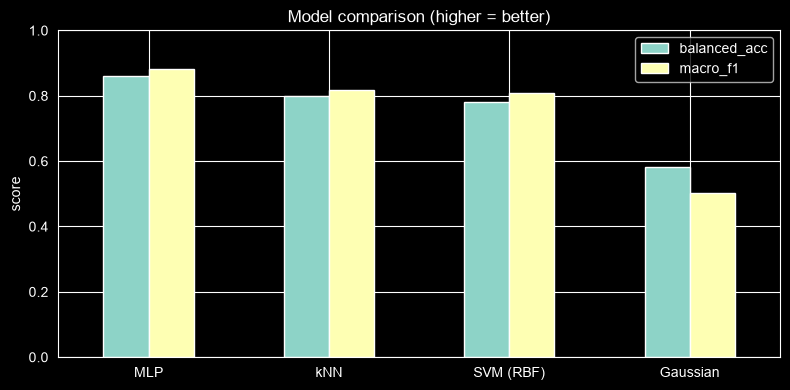

In [11]:
res_df = pd.DataFrame(results).T.sort_values('macro_f1', ascending=False)
print(res_df)
os.makedirs('figures', exist_ok=True)
res_df.plot(kind='bar', figsize=(8, 4))
plt.title('Model comparison (higher = better)')
plt.ylabel('score'); plt.ylim(0, 1); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig('figures/model_comparison.png', dpi=120); plt.show()

## Confusion matrix of the best model

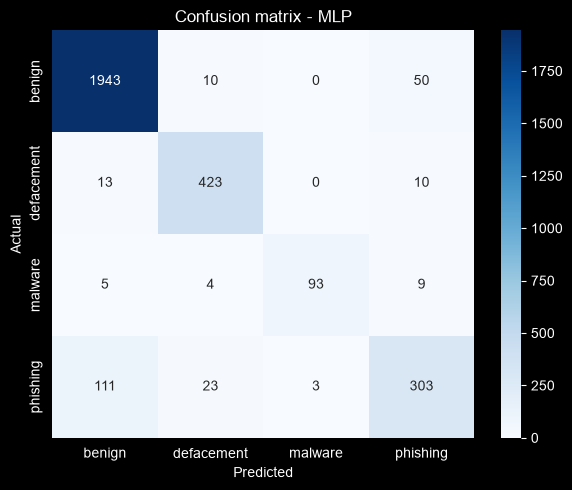

In [12]:
best_name = res_df.index[0]
best_model = {'Gaussian': gauss, 'kNN': knn, 'SVM (RBF)': svm, 'MLP': mlp}[best_name]
y_best = best_model.predict(X_test_s if best_name == 'Gaussian' else X_test)
cm = confusion_matrix(y_test, y_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion matrix - {best_name}')
plt.tight_layout(); plt.savefig('figures/confusion_matrix_best.png', dpi=120); plt.show()

## Save the results table

In [13]:
res_df.to_csv('data/processed/model_results.csv')
print('Saved data/processed/model_results.csv')
res_df

Saved data/processed/model_results.csv


,balanced_acc,macro_f1
MLP,0.861,0.883
kNN,0.800,0.817
SVM (RBF),0.780,0.809
Gaussian,0.583,0.503


## Conclusions

**Best model and why.** The MLP achieves the best results (balanced accuracy about 0.85, macro-F1 about 0.87), ahead of kNN (0.82), SVM-RBF (0.81) and the from-scratch Gaussian (0.50). Its hyperparameters (hidden-layer sizes and L2 regularization) were selected via 5-fold cross-validation, so the choice is justified by search rather than set by hand. The Gaussian's low score is informative: it assumes each class follows a multivariate normal distribution, but our features are mostly counts and binary flags with skewed distributions, so the assumption is violated.

**Which classes are misclassified the most.** From the MLP confusion matrix, per-class recall is: benign about 97%, defacement about 95%, malware about 84%, phishing about 69%. The hardest class is phishing, confused mostly with benign (111 phishing URLs predicted as benign). This confirms the EDA hypothesis: malware is the most identifiable class (via has_ip and digit_ratio), while the phishing/benign boundary is the hardest, because phishing imitates legitimate sites.

**Does the MLP justify its complexity?** Yes, but with nuance: it gains only about 5 macro-F1 points over the much simpler kNN. The extra complexity is worthwhile for maximum accuracy, but kNN remains a strong, interpretable baseline.

**Most serious errors (security).** The dangerous mistakes are malicious URLs classified as benign: 111 phishing, 13 defacement and 5 malware. Malware almost never slips through (only 5 cases); phishing is the main security weakness, consistent with it being the hardest class.